<a href="https://colab.research.google.com/github/nicolejanoff/Test/blob/main/projekt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Concentration: 0.0025 µM
Expected response: 0.9999972222299383
Error: 0.003290903507043691
Observed response: 1.003288125736982

Concentration: 0.01 µM
Expected response: 0.9999555575307764
Error: 0.009114395886526527
Observed response: 1.0090699534173029

Concentration: 0.04 µM
Expected response: 0.9992893942085628
Error: 0.011711430283736696
Observed response: 1.0110008244922994

Concentration: 0.16 µM
Expected response: 0.9887502197222711
Error: -0.003856242324655014
Observed response: 0.9848939773976161

Concentration: 0.64 µM
Expected response: 0.8459918784779666
Error: 0.013569793501185028
Observed response: 0.8595616719791517

Concentration: 2.0 µM
Expected response: 0.36
Error: -0.011501170701405597
Observed response: 0.3484988292985944

Concentration: 4.0 µM
Expected response: 0.12328767123287672
Error: 0.014357296617537625
Observed response: 0.13764496785041436

Concentration: 8.0 µM
Expected response: 0.033962264150943396
Error: -0.010427598971524867
Observed response: 0.023

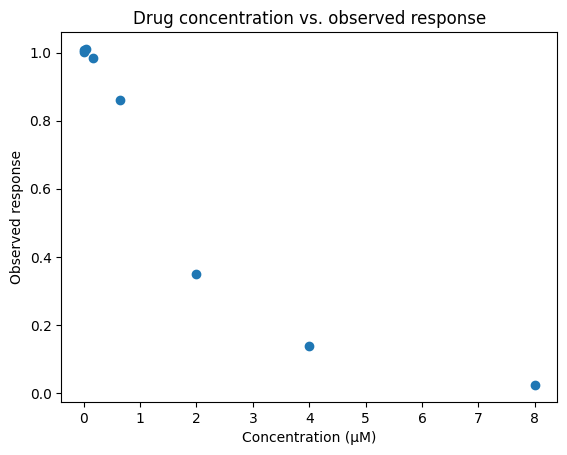

NLL for the chosen parameters: -25.103785861923015
Estimated EC50: 1.51
Estimated h: 2.05
NLL: -25.390403101329248


In [4]:
# Project card

## The paper
## The data object
## The random variable chosen
## What the paper does
## The generative model proposed
## Parameters and assumptions
## The forward simulation
## The parameterization/fitting
## What/if the model adds to the paper
## Model limitations/how it breaks


# 1. Introduction

# 2. Generative model

## 2.1 Hill model
import matplotlib.pyplot as plt
import random

# Simplify the Hill model to 2 parameters EC50 and h

def mu(c):
  return 1 /(1 + (c / EC50)**h)


## 2.2 Measurement model
# concentration range: 8 µM to 2.5 nM (8 point dose response assays) according to article, values inbetween were chosen arbitrarily

## 2.3 Assumptions
EC50 = 1.5
h = 2
conc = [0.0025, 0.01, 0.04, 0.16, 0.64, 2.0, 4.0, 8.0] # µM
mu_E = 0
sigma_E = 0.01

# 3. Forward simulation
observations = []

for c in conc:
  expected_response = mu(c)
  E = random.gauss(mu_E, sigma_E)
  observation = mu(c) + E
  observations.append(observation)


## 3.1 One observation
  print("Concentration:", c, "µM")
  print("Expected response:", expected_response)
  print("Error:", E)
  print("Observed response:", observation)
  print()


## 3.2 Full dose-response experiment
plt.scatter(conc, observations, label = "Simulated observations")
plt.xlabel("Concentration (µM)")
plt.ylabel("Observed response")
plt.title("Drug concentration vs. observed response")
plt.show()


# 4. Parameter estimation
import math

## 4.1 NLL
def nll(observations, theta):
  """NLL(theta) = - sum log p(y_i | theta)."""
  total = 0.0
  EC50, h = theta

  for i in range(len(observations)):
    x = observations[i]
    c = conc[i]

    mu = 1 /(1 + (c / EC50) ** h)

    log_p = (-0.5 * math.log(2 * math.pi * sigma_E**2) - (x - mu)**2 / (2 * sigma_E ** 2))

    total = total - log_p

  return total

theta = (1.5, 2)
result = nll(observations, theta)
print("NLL for the chosen parameters:", result)

## 4.2 MLE
EC50_hat = None
h_hat = None

best = float("inf")

for a in range(201):
  EC50 = 0.5 + 0.01 * a

  for b in range(251):
    h = 0.5 + 0.01 * b

    score = nll(observations, (EC50, h))

    if score < best:
      best = score
      EC50_hat = EC50
      h_hat = h

print("Estimated EC50:", EC50_hat)
print("Estimated h:", h_hat)
print("NLL:", best)


# true parameters vs estimated parameters


# 5. Parameter recovery

#Repeat simulation 100/500 times.

#Plot:
#EC50 estimates
#h estimates


# 6. Uncertainty

#Parametric bootstrap.

#95% CI for EC50 and h.


# 7. Model failure

#Increase sigma.

#Show:
#noise -> worse parameter recovery


# 8. Discussion

## Interpretation
## Relation to paper
## Limitations
## What model adds


# 9. Conclusion